# TAE-IA · Module 6 · L19 — Speech Recognition with Whisper: Audio to Text

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L19 |
| **Track** | B — Audio |
| **Runtime** | T4 GPU (speeds up Whisper ~4–6×) |
| **Drive space** | ~2 GB new (Whisper small + medium weights) |

## Learning objectives

By the end of this notebook you will be able to:
1. Load Whisper models of different sizes and understand the speed/accuracy trade-off
2. Transcribe audio in English and Spanish with automatic language detection
3. Force a language or switch to translation mode with `task="translate"`
4. Compute WER using `jiwer` with correct normalisation
5. Build a model-size comparison table (tiny / small / medium) on multiple audio conditions

---

## Cell 0 — Setup

In [ ]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random, time
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'
os.makedirs(MODEL_CACHE, exist_ok=True)

os.environ['HF_HOME']            = MODEL_CACHE
os.environ['TORCH_HOME']         = MODEL_CACHE
os.environ['TRANSFORMERS_CACHE'] = os.path.join(MODEL_CACHE, 'hub')

# openai-whisper does NOT read TORCH_HOME -- left to itself it caches to
# ~/.cache/whisper on the ephemeral runtime disk. Every load_model() call
# below passes download_root=WHISPER_CACHE explicitly; that is what puts the
# weights on Drive and lets L20 reuse them without re-downloading.
WHISPER_CACHE = MODEL_CACHE

SEED = 42
random.seed(SEED); np.random.seed(SEED)

import torch
if not torch.cuda.is_available():
    print('\nNo GPU — go to Runtime > Change runtime type > T4 GPU')
    print('Whisper will still run on CPU but ~4× slower.')
else:
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Mounted at /content/drive

No GPU — go to Runtime > Change runtime type > T4 GPU
Whisper will still run on CPU but ~4× slower.
Device: cpu


In [ ]:
!pip install openai-whisper jiwer gtts pydub librosa soundfile -q

import whisper
from jiwer import wer, process_words
from gtts import gTTS
import librosa
import matplotlib.pyplot as plt
import IPython.display as ipd

print(f'whisper {whisper.__version__}')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 12.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.0/248.0 MB 5.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spacy 3.8.16 requires click<9.0.0,>=8.2.1, but you have click 8.1.8 which is incompatible.
huggingface-hub 1.29.0 requires click<9.0.0,>=8.4.2, but you have click 8.1.8 which is incompatible.
wandb 0.28.1 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.
whisper 20250625


---
## Section 2.1 — Generate Test Audio Files

We use `gTTS` (Google Text-to-Speech) to synthesise test audio with **exactly known ground truth text**. This makes WER measurement unambiguous — no manual transcription required.

| Condition | Why it matters |
|---|---|
| Clear English | Baseline — should give near-zero WER |
| Clear Spanish | Tests multilingual capability |
| Fast English | gTTS `slow=False` produces faster delivery |
| Technical terms | Numbers, domain words (mel spectrogram, etc.) |
| Noisy English | Add white noise at different SNRs — tests robustness |

In [ ]:
AUDIO_DIR = '/tmp/L19_audio'
os.makedirs(AUDIO_DIR, exist_ok=True)

# Ground truth references — keep lowercase, no punctuation (for WER)
REFERENCES = {
    'clear_en':  'the artificial intelligence model processes audio signals in real time',
    'clear_es':  'la inteligencia artificial procesa señales de audio en tiempo real',
    'fast_en':   'machine learning models learn patterns from large amounts of training data',
    'technical': 'the mel spectrogram uses one hundred twenty eight frequency bands',
    'noisy_en':  'the artificial intelligence model processes audio signals in real time',
}

# gTTS text (with punctuation for natural TTS prosody; reference is lowercase/stripped)
TTS_TEXT = {
    'clear_en':  ('The artificial intelligence model processes audio signals in real time.', 'en', False),
    'clear_es':  ('La inteligencia artificial procesa señales de audio en tiempo real.', 'es', False),
    'fast_en':   ('Machine learning models learn patterns from large amounts of training data.', 'en', False),
    'technical': ('The mel spectrogram uses one hundred twenty eight frequency bands.', 'en', False),
    'noisy_en':  ('The artificial intelligence model processes audio signals in real time.', 'en', False),
}

# The clips ship as a zip on Drive. Thirty students calling Google's TTS in the
# same thirty seconds is a rate-limit waiting to happen, and identical clips also
# make every team's WER table comparable with the answer key. When the bundle is
# missing we generate them live instead -- same sentences, same call, made now.
import zipfile

AUDIO_ZIP_CANDIDATES = [
    '/content/drive/MyDrive/TAE_IA_M6/assets/L19_audio.zip',
    '/content/drive/MyDrive/TAE_IA_M6/L19_audio.zip',
]
bundle = next((p for p in AUDIO_ZIP_CANDIDATES if os.path.exists(p)), None)
if bundle:
    with zipfile.ZipFile(bundle) as zf:
        zf.extractall(AUDIO_DIR)
    print(f'Clips: extracted from {bundle}')
else:
    print('Clips: no bundle on Drive, generating with gTTS (needs internet).')

for name, (text, lang, slow) in TTS_TEXT.items():
    mp3_path = os.path.join(AUDIO_DIR, f'{name}.mp3')
    if not os.path.exists(mp3_path):        # absent from the bundle, or no bundle
        tts = gTTS(text=text, lang=lang, slow=slow)
        tts.save(mp3_path)
    print(f'  {name}: {mp3_path}')

# Add noise to noisy_en by mixing with white noise
y_clean, sr = librosa.load(os.path.join(AUDIO_DIR, 'noisy_en.mp3'), sr=16000, mono=True)
rng = np.random.default_rng(SEED)
# SNR ~ 5 dB — perceptibly noisy but still intelligible
signal_power = np.mean(y_clean ** 2)
noise_power  = signal_power / (10 ** (5 / 10))
noise        = rng.normal(0, np.sqrt(noise_power), len(y_clean)).astype(np.float32)
y_noisy      = np.clip(y_clean + noise, -1.0, 1.0)

import soundfile as sf
noisy_wav = os.path.join(AUDIO_DIR, 'noisy_en_5db.wav')
sf.write(noisy_wav, y_noisy, sr)
print(f'  noisy_en (5 dB SNR): {noisy_wav}')
# Override noisy reference key to use the wav file
AUDIO_PATHS = {
    'clear_en':  os.path.join(AUDIO_DIR, 'clear_en.mp3'),
    'clear_es':  os.path.join(AUDIO_DIR, 'clear_es.mp3'),
    'fast_en':   os.path.join(AUDIO_DIR, 'fast_en.mp3'),
    'technical': os.path.join(AUDIO_DIR, 'technical.mp3'),
    'noisy_en':  noisy_wav,
}

Clips: extracted from /content/drive/MyDrive/TAE_IA_M6/assets/L19_audio.zip
  clear_en: /tmp/L19_audio/clear_en.mp3
  clear_es: /tmp/L19_audio/clear_es.mp3
  fast_en: /tmp/L19_audio/fast_en.mp3
  technical: /tmp/L19_audio/technical.mp3
  noisy_en: /tmp/L19_audio/noisy_en.mp3
  noisy_en (5 dB SNR): /tmp/L19_audio/noisy_en_5db.wav


In [ ]:
# Listen to all test clips before transcribing
for name, path in AUDIO_PATHS.items():
    y, sr = librosa.load(path, sr=16000, mono=True)
    print(f'\n▶ {name}  ({len(y)/sr:.1f}s)  ref: "{REFERENCES[name]}"')
    ipd.display(ipd.Audio(y, rate=sr))


▶ clear_en  (5.2s)  ref: "the artificial intelligence model processes audio signals in real time"



▶ clear_es  (5.2s)  ref: "la inteligencia artificial procesa señales de audio en tiempo real"



▶ fast_en  (4.7s)  ref: "machine learning models learn patterns from large amounts of training data"



▶ technical  (4.7s)  ref: "the mel spectrogram uses one hundred twenty eight frequency bands"



▶ noisy_en  (5.2s)  ref: "the artificial intelligence model processes audio signals in real time"


---
## Section 2.2 — WER Normalisation Helper

WER is sensitive to case, punctuation, and extra whitespace. Always normalise both reference and hypothesis identically before computing.

In [ ]:
import re

def normalise(text):
    """Lowercase, remove punctuation, collapse whitespace."""
    text = text.lower().strip()
    text = re.sub(r"[^a-záéíóúüñ\s]", " ", text)  # keep Spanish chars
    text = re.sub(r"\s+", " ", text).strip()
    return text

def compute_wer(reference, hypothesis):
    ref = normalise(reference)
    hyp = normalise(hypothesis)
    score = wer(ref, hyp)
    details = process_words(ref, hyp)
    return score, ref, hyp, details

# Demo
ref  = "The mel spectrogram uses one hundred twenty eight frequency bands."
hyp1 = "The mel spectrogram uses 128 frequency bands."
hyp2 = "the mel spectrogram uses one hundred twenty eight frequency bands"

for label, h in [('number mismatch', hyp1), ('perfect match', hyp2)]:
    score, r, h_norm, det = compute_wer(ref, h)
    print(f'{label}: WER={score:.3f}  S={det.substitutions} D={det.deletions} I={det.insertions}')
    print(f'  ref: {r}')
    print(f'  hyp: {h_norm}')

number mismatch: WER=0.400  S=0 D=4 I=0
  ref: the mel spectrogram uses one hundred twenty eight frequency bands
  hyp: the mel spectrogram uses frequency bands
perfect match: WER=0.000  S=0 D=0 I=0
  ref: the mel spectrogram uses one hundred twenty eight frequency bands
  hyp: the mel spectrogram uses one hundred twenty eight frequency bands


---
## Section 2.3 — Transcribe with Whisper Small

Load `whisper-small` (~244M parameters, ~460 MB) and transcribe all 5 conditions.

In [ ]:
print('Loading Whisper small (~460 MB, cached to Drive after first download)...')
t0 = time.time()
model_small = whisper.load_model('small', download_root=WHISPER_CACHE)
print(f'Loaded in {time.time()-t0:.1f}s  |  '
      f'params: {sum(p.numel() for p in model_small.parameters())/1e6:.0f}M')

if DEVICE == 'cuda':
    model_small = model_small.to('cuda')

Loading Whisper small (~460 MB, cached to Drive after first download)...


100%|███████████████████████████████████████| 461M/461M [00:08<00:00, 55.9MiB/s]


Loaded in 19.9s  |  params: 241M


In [ ]:
small_results = {}

print(f'Transcribing 5 conditions with Whisper small...\n')
for name, path in AUDIO_PATHS.items():
    t0 = time.time()
    result = model_small.transcribe(path, fp16=(DEVICE == 'cuda'))
    elapsed = time.time() - t0

    score, ref_n, hyp_n, det = compute_wer(REFERENCES[name], result['text'])
    small_results[name] = {
        'hypothesis':     result['text'].strip(),
        'hyp_normalised': hyp_n,
        'ref_normalised': ref_n,
        'wer':            score,
        'language':       result['language'],
        'time_s':         elapsed,
        'S': det.substitutions, 'D': det.deletions, 'I': det.insertions,
    }

    print(f'[{name}]')
    print(f'  Language detected : {result["language"]}')
    print(f'  Transcription     : {result["text"].strip()}')
    print(f'  WER               : {score:.3f}  (S={det.substitutions} D={det.deletions} I={det.insertions})')
    print(f'  Time              : {elapsed:.2f}s')
    print()

Transcribing 5 conditions with Whisper small...

[clear_en]
  Language detected : en
  Transcription     : The artificial intelligence model processes audio signals in real time.
  WER               : 0.000  (S=0 D=0 I=0)
  Time              : 19.62s

[clear_es]
  Language detected : es
  Transcription     : La Inteligencia Artificial procesa señales de audio en tiempo real.
  WER               : 0.000  (S=0 D=0 I=0)
  Time              : 17.54s

[fast_en]
  Language detected : en
  Transcription     : Machine learning models learn patterns from large amounts of training data.
  WER               : 0.000  (S=0 D=0 I=0)
  Time              : 17.16s

[technical]
  Language detected : en
  Transcription     : The Mel Spectrogram uses 128 frequency bands.
  WER               : 0.400  (S=0 D=4 I=0)
  Time              : 17.02s

[noisy_en]
  Language detected : en
  Transcription     : The artificial intelligence model processes audio signals in real time.
  WER               : 0.000  (S=0 D

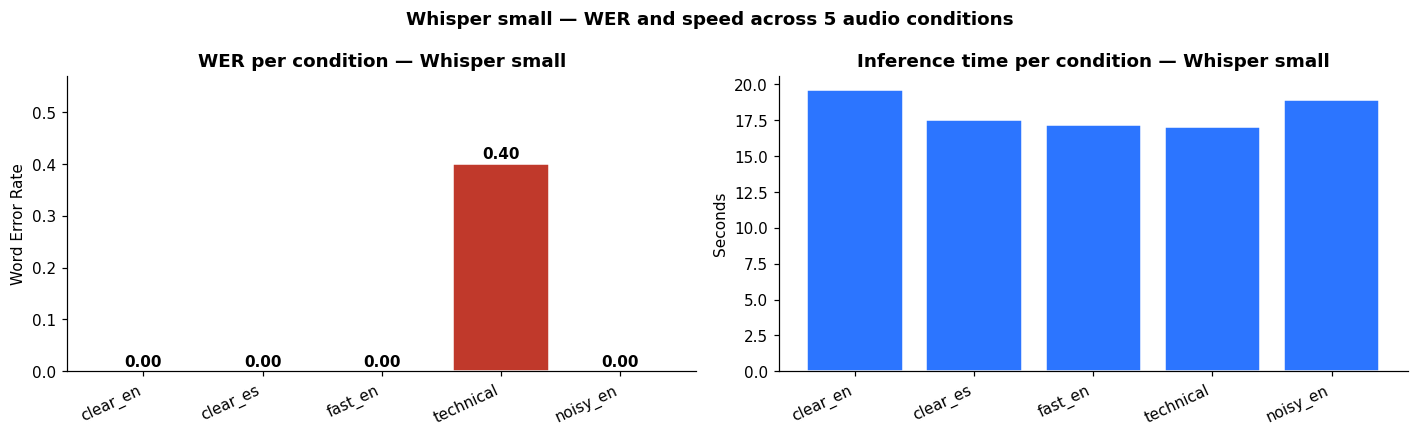

In [ ]:
names  = list(small_results.keys())
wers   = [small_results[n]['wer']    for n in names]
times  = [small_results[n]['time_s'] for n in names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

colours = ['#27ae60' if w == 0 else '#e67e22' if w < 0.2 else '#c0392b' for w in wers]
ax1.bar(names, wers, color=colours, edgecolor='white')
ax1.set_title('WER per condition — Whisper small', fontweight='bold')
ax1.set_ylabel('Word Error Rate')
ax1.set_ylim(0, max(wers) * 1.3 + 0.05)
for i, w in enumerate(wers):
    ax1.text(i, w + 0.01, f'{w:.2f}', ha='center', fontsize=10, fontweight='bold')
plt.setp(ax1.get_xticklabels(), rotation=25, ha='right')

ax2.bar(names, times, color='#2C75FF', edgecolor='white')
ax2.set_title('Inference time per condition — Whisper small', fontweight='bold')
ax2.set_ylabel('Seconds')
plt.setp(ax2.get_xticklabels(), rotation=25, ha='right')

plt.suptitle('Whisper small — WER and speed across 5 audio conditions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2.4 — Model Size Comparison: tiny vs. small vs. medium

Run all three model sizes on the same 5 clips and build a WER × speed table.

**Expected runtime:** ~10–15 min total (medium is the slowest at ~2s/clip on T4).

In [ ]:
MODEL_SIZES = ['tiny', 'small', 'medium']
comparison  = {}  # model_name → {condition → {wer, time}}

for size in MODEL_SIZES:
    print(f'\nLoading Whisper {size}...')
    m = whisper.load_model(size, download_root=WHISPER_CACHE)
    if DEVICE == 'cuda':
        m = m.to('cuda')

    comparison[size] = {}
    for name, path in AUDIO_PATHS.items():
        t0     = time.time()
        result = m.transcribe(path, fp16=(DEVICE == 'cuda'))
        elapsed = time.time() - t0
        score, _, _, _ = compute_wer(REFERENCES[name], result['text'])
        comparison[size][name] = {'wer': score, 'time_s': elapsed}

    # Free GPU memory before loading next model
    del m
    torch.cuda.empty_cache()

print('\nDone.')


Loading Whisper tiny...


100%|█████████████████████████████████████| 72.1M/72.1M [00:01<00:00, 60.6MiB/s]



Loading Whisper small...

Loading Whisper medium...


100%|█████████████████████████████████████| 1.42G/1.42G [00:22<00:00, 69.4MiB/s]



Done.


In [ ]:
import pandas as pd

# WER table
wer_data  = {size: {n: comparison[size][n]['wer']    for n in AUDIO_PATHS} for size in MODEL_SIZES}
time_data = {size: {n: comparison[size][n]['time_s'] for n in AUDIO_PATHS} for size in MODEL_SIZES}

df_wer  = pd.DataFrame(wer_data).T
df_time = pd.DataFrame(time_data).T
df_wer['mean_WER']      = df_wer.mean(axis=1)
df_time['mean_time_s']  = df_time.mean(axis=1)

print('=== WER by model and condition ===')
print(df_wer.round(3).to_string())
print()
print('=== Inference time (s) by model and condition ===')
print(df_time.round(2).to_string())

=== WER by model and condition ===
        clear_en  clear_es  fast_en  technical  noisy_en  mean_WER
tiny         0.0       0.0      0.0        0.6       0.6      0.24
small        0.0       0.0      0.0        0.4       0.0      0.08
medium       0.0       0.0      0.0        0.4       0.0      0.08

=== Inference time (s) by model and condition ===
        clear_en  clear_es  fast_en  technical  noisy_en  mean_time_s
tiny        1.97      2.00     1.96       1.94      2.50         2.08
small      16.80     17.14    16.95      17.60     17.39        17.17
medium     58.46     59.12    57.91      57.58     57.58        58.13


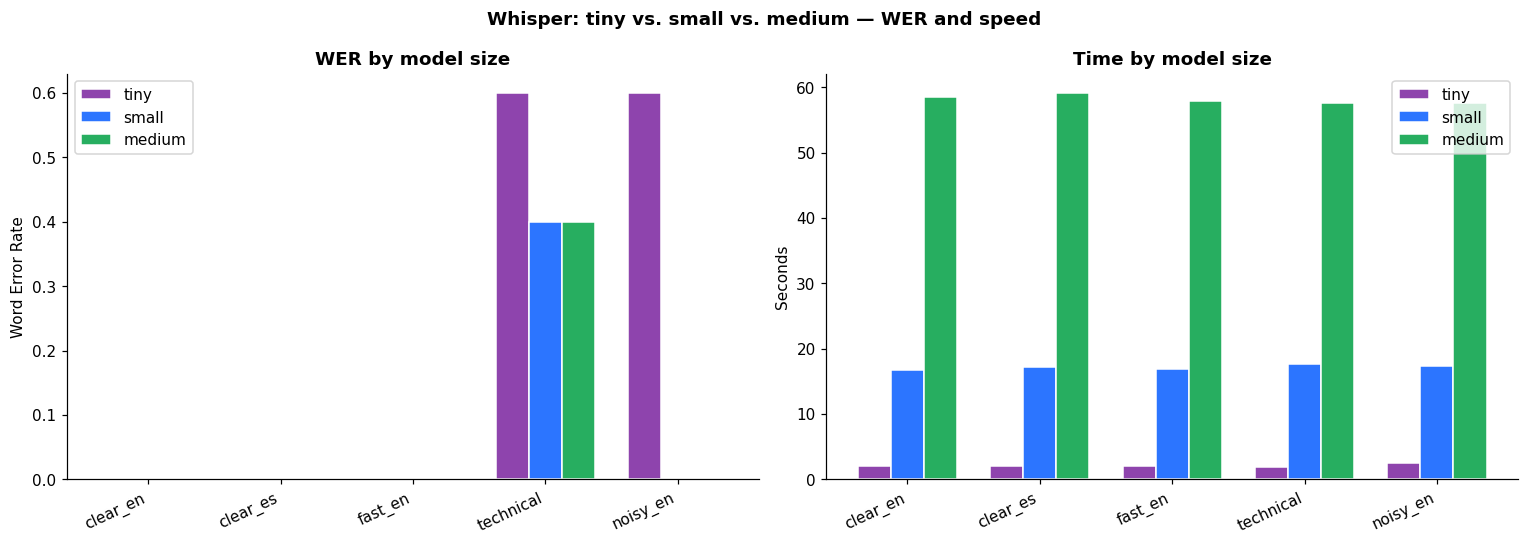

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
conditions = list(AUDIO_PATHS.keys())
x   = np.arange(len(conditions))
w   = 0.25
c   = {'tiny': '#8e44ad', 'small': '#2C75FF', 'medium': '#27ae60'}

for i, size in enumerate(MODEL_SIZES):
    wer_vals  = [comparison[size][n]['wer']    for n in conditions]
    time_vals = [comparison[size][n]['time_s'] for n in conditions]
    ax1.bar(x + i*w, wer_vals,  width=w, label=size, color=c[size], edgecolor='white')
    ax2.bar(x + i*w, time_vals, width=w, label=size, color=c[size], edgecolor='white')

for ax, title, ylabel in [
    (ax1, 'WER by model size',   'Word Error Rate'),
    (ax2, 'Time by model size',  'Seconds'),
]:
    ax.set_xticks(x + w); ax.set_xticklabels(conditions, rotation=25, ha='right')
    ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylabel)
    ax.legend()

plt.suptitle('Whisper: tiny vs. small vs. medium — WER and speed', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 2.5 — Language Detection, Spanish, and Translation Mode

Whisper's first 30 seconds are used to detect language. We test four modes on the Spanish clip.

In [ ]:
# Reload small model (freed earlier)
m_small = whisper.load_model('small', download_root=WHISPER_CACHE)
if DEVICE == 'cuda':
    m_small = m_small.to('cuda')

es_path = AUDIO_PATHS['clear_es']
es_ref  = REFERENCES['clear_es']

print('Testing language modes on Spanish clip:')
print(f'Reference: "{es_ref}"\n')

# Mode 1: auto-detect (default)
r1 = m_small.transcribe(es_path, fp16=(DEVICE == 'cuda'))
s1, _, _, _ = compute_wer(es_ref, r1['text'])
print(f'1. Auto-detect:')
print(f'   Language: {r1["language"]}')
print(f'   Output:   {r1["text"].strip()}')
print(f'   WER:      {s1:.3f}\n')

# Mode 2: force English (will phonetically mangle Spanish)
r2 = m_small.transcribe(es_path, language='en', fp16=(DEVICE == 'cuda'))
print(f'2. Forced English:')
print(f'   Output: {r2["text"].strip()}')
print(f'   (WER vs Spanish ref meaningless here)\n')

# Mode 3: force Spanish
r3 = m_small.transcribe(es_path, language='es', fp16=(DEVICE == 'cuda'))
s3, _, _, _ = compute_wer(es_ref, r3['text'])
print(f'3. Forced Spanish:')
print(f'   Output: {r3["text"].strip()}')
print(f'   WER:    {s3:.3f}\n')

# Mode 4: translate Spanish → English
r4 = m_small.transcribe(es_path, task='translate', fp16=(DEVICE == 'cuda'))
print(f'4. Translation (Spanish → English):')
print(f'   Output: {r4["text"].strip()}')
print(f'   (Compare with expected: "artificial intelligence processes audio signals in real time")')

Testing language modes on Spanish clip:
Reference: "la inteligencia artificial procesa señales de audio en tiempo real"

1. Auto-detect:
   Language: es
   Output:   La Inteligencia Artificial procesa señales de audio en tiempo real.
   WER:      0.000

2. Forced English:
   Output: La Inteligencia Artificial procesa señales de audio en tiempo real.
   (WER vs Spanish ref meaningless here)

3. Forced Spanish:
   Output: La Inteligencia Artificial procesa señales de audio en tiempo real.
   WER:    0.000

4. Translation (Spanish → English):
   Output: Artificial Intelligence processes audio signals in real time.
   (Compare with expected: "artificial intelligence processes audio signals in real time")


---
## Section 2.6 — Noise Robustness: WER vs. SNR

Generate the clean English sentence at 5 different SNR levels and measure how WER degrades.

SNR (dB)  WER    Transcription
--------------------------------------------------------------------------------
      20  0.000  The artificial intelligence model processes audio signals in
      10  0.000  the artificial intelligence model processes audio signals in
       5  0.000  The artificial intelligence model processes audio signals in
       0  0.000  The artificial intelligence model processes audio signals in
      -5  0.300  The artificial intelligence models process their audio signa


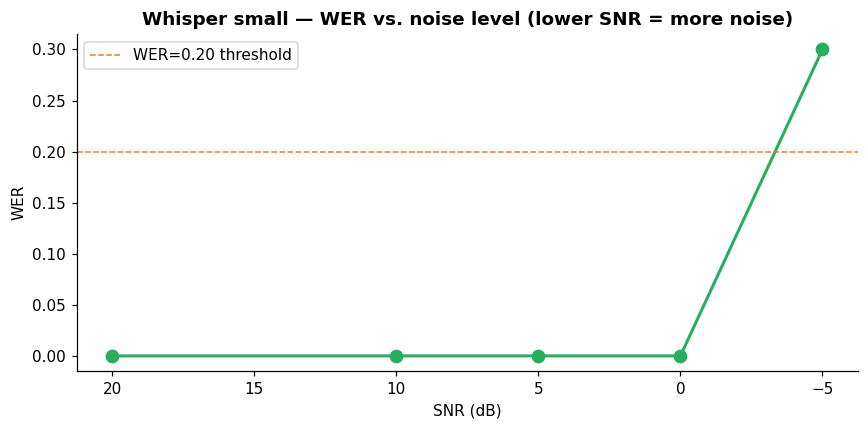

In [ ]:
y_base, sr_base = librosa.load(AUDIO_PATHS['clear_en'], sr=16000, mono=True)
sig_power = np.mean(y_base ** 2)
snr_levels = [20, 10, 5, 0, -5]   # dB
ref_en = REFERENCES['clear_en']
rng = np.random.default_rng(SEED)   # reseed: same noise, same curve, every run

snr_results = []
print('SNR (dB)  WER    Transcription')
print('-' * 80)

for snr_db in snr_levels:
    noise_power = sig_power / (10 ** (snr_db / 10))
    noise       = rng.normal(0, np.sqrt(noise_power), len(y_base)).astype(np.float32)
    y_noisy     = np.clip(y_base + noise, -1.0, 1.0)

    # Save to temp wav
    tmp_path = f'/tmp/snr_{snr_db}.wav'
    sf.write(tmp_path, y_noisy, sr_base)

    result = m_small.transcribe(tmp_path, fp16=(DEVICE == 'cuda'), language='en')
    score, _, _, _ = compute_wer(ref_en, result['text'])
    snr_results.append((snr_db, score))
    hyp_short = result['text'].strip()[:60]
    print(f'{snr_db:>8}  {score:.3f}  {hyp_short}')

# Plot WER vs. SNR
fig, ax = plt.subplots(figsize=(8, 4))
snrs, wers_snr = zip(*snr_results)
ax.plot(snrs, wers_snr, 'o-', color='#27ae60', linewidth=2, markersize=8)
ax.axhline(0.2, color='#e67e22', linewidth=1, linestyle='--', label='WER=0.20 threshold')
ax.set_xlabel('SNR (dB)'); ax.set_ylabel('WER')
ax.set_title('Whisper small — WER vs. noise level (lower SNR = more noise)', fontweight='bold')
ax.invert_xaxis()   # noisy on the right → clean on the left
ax.legend()
plt.tight_layout()
plt.show()

---
## Exercise 1 — Code-switching

Code-switching is mid-sentence language alternation, common in bilingual communities (e.g., Spanglish).

1. Create a TTS audio that mixes English and Spanish: e.g., `"The modelo de inteligencia artificial processes audio"`
2. Transcribe with `auto-detect`, `language='en'`, and `language='es'`
3. Which mode produces the most readable output? Does Whisper handle code-switching gracefully?
4. Compute WER for each mode against a reasonable ground truth.

In [ ]:
# Exercise 1 -- Code-switching

# Given: a mixed-language clip. gTTS has no code-switching voice, so we feed the
# mixed text to the English voice -- imperfect, and enough to make the point.
mixed_text = "The modelo de inteligencia artificial processes audio signals."
mixed_path = os.path.join(AUDIO_DIR, 'codeswitching.mp3')   # ships in the bundle
if not os.path.exists(mixed_path):
    gTTS(text=mixed_text, lang='en').save(mixed_path)

y_mix, sr_mix = librosa.load(mixed_path, sr=16000)
print('Code-switching clip:')
ipd.display(ipd.Audio(y_mix, rate=sr_mix))

# TODO 1: transcribe in auto-detect, forced English, and forced Spanish modes.
modes = {'auto': {}, 'forced_en': {'language': 'en'}, 'forced_es': {'language': 'es'}}
mixed_results = {}

# TODO 2: use the original bilingual sentence as the explicit reference.
mixed_reference = normalise(mixed_text)
print(f'Ground-truth reference: "{mixed_reference}"\n')

for mode_name, mode_args in modes.items():
    result = m_small.transcribe(mixed_path, fp16=(DEVICE == 'cuda'), **mode_args)
    score, _, _, details = compute_wer(mixed_reference, result['text'])
    mixed_results[mode_name] = {'text': result['text'].strip(),
                                'language': result['language'], 'wer': score}
    print(f'[{mode_name}]')
    print(f'  Detected/forced language: {result["language"]}')
    print(f'  Transcription: {result["text"].strip()}')
    print(f'  WER: {score:.3f} (S={details.substitutions}, D={details.deletions}, I={details.insertions})\n')

# TODO 3: identify the lowest-WER mode.
best_mode = min(mixed_results, key=lambda name: mixed_results[name]['wer'])
print(f'Lowest-WER mode: {best_mode} ({mixed_results[best_mode]["wer"]:.3f})')

# TODO 4 is answered in the markdown cell below.


Code-switching clip:


Ground-truth reference: "the modelo de inteligencia artificial processes audio signals"

[auto]
  Detected/forced language: en
  Transcription: The Modelo de Inteligencia artificial processes audio signals.
  WER: 0.000 (S=0, D=0, I=0)

[forced_en]
  Detected/forced language: en
  Transcription: The Modelo de Inteligencia artificial processes audio signals.
  WER: 0.000 (S=0, D=0, I=0)

[forced_es]
  Detected/forced language: es
  Transcription: los audio-signales artificiales de la inteligencia Modelo de
  WER: 1.125 (S=4, D=2, I=3)

Lowest-WER mode: auto (0.000)


**Exercise 1 — Answer:**

The **auto-detect** and **forced English** modes produced the same correct transcription, with a WER of **0.000**. Both outputs were equally readable. Auto-detect selected English because the bilingual sentence was generated with an English gTTS voice.

The forced Spanish mode changed the sentence significantly and produced a WER of **1.125**, with four substitutions, two deletions, and three insertions. This shows that forcing the wrong language can damage code-switching transcription.

Whisper handled this synthetic code-switching example gracefully in auto and English modes. However, choosing the reference is difficult because bilingual speech has no completely neutral transcription, and different speakers may pronounce or write the mixed words differently.

---
## Exercise 2 — WER normalisation sensitivity

Run `compute_wer(REFERENCES['technical'], hypothesis)` where `hypothesis` is the raw Whisper output for the technical condition — **without** applying `normalise()` to either string.

1. What is the WER without normalisation?
2. What is the WER with normalisation?
3. What specific token differences cause the gap (capitalisation? punctuation? numbers written as digits vs. words?)?

This exercise shows why WER is only comparable across systems when identical normalisation is applied.

In [ ]:
# Exercise 2 -- WER normalisation sensitivity

# Given: the raw hypothesis for the `technical` condition, and its reference.
technical_result = m_small.transcribe(AUDIO_PATHS['technical'], fp16=(DEVICE == 'cuda'))
hyp_raw = technical_result['text'].strip()
ref_raw = REFERENCES['technical']
print(f'Reference  : "{ref_raw}"')
print(f'Hypothesis : "{hyp_raw}"')

# TODO 1: calculate raw and normalised WER.
wer_raw = wer(ref_raw, hyp_raw)
wer_normalised, ref_norm, hyp_norm, norm_details = compute_wer(ref_raw, hyp_raw)
wer_gap = wer_raw - wer_normalised
raw_details = process_words(ref_raw, hyp_raw)

print(f'\nWER without normalisation: {wer_raw:.3f}')
print(f'WER with normalisation:    {wer_normalised:.3f}')
print(f'Normalisation gap:         {wer_gap:.3f}')

# TODO 2: display token differences and error counts.
print(f'\nRaw reference tokens:  {ref_raw.split()}')
print(f'Raw hypothesis tokens: {hyp_raw.split()}')
print(f'Normalised reference:  {ref_norm}')
print(f'Normalised hypothesis: {hyp_norm}')
print(f'Raw errors: S={raw_details.substitutions}, D={raw_details.deletions}, I={raw_details.insertions}')
print(f'Normalised errors: S={norm_details.substitutions}, D={norm_details.deletions}, I={norm_details.insertions}')

# TODO 3 is answered in the markdown cell below.


Reference  : "the mel spectrogram uses one hundred twenty eight frequency bands"
Hypothesis : "The Mel Spectrogram uses 128 frequency bands."

WER without normalisation: 0.800
WER with normalisation:    0.400
Normalisation gap:         0.400

Raw reference tokens:  ['the', 'mel', 'spectrogram', 'uses', 'one', 'hundred', 'twenty', 'eight', 'frequency', 'bands']
Raw hypothesis tokens: ['The', 'Mel', 'Spectrogram', 'uses', '128', 'frequency', 'bands.']
Normalised reference:  the mel spectrogram uses one hundred twenty eight frequency bands
Normalised hypothesis: the mel spectrogram uses frequency bands
Raw errors: S=5, D=3, I=0
Normalised errors: S=0, D=4, I=0


**Exercise 2 — Answer:**

The WER without normalisation was **0.800**, while the normalised WER was **0.400**. The gap was **0.400**.

Without normalisation, `The`, `Mel`, and `Spectrogram` were different from their lowercase reference words. The final token `bands.` was also different from `bands` because of punctuation. In addition, Whisper wrote `128` instead of `one hundred twenty eight`.

The current `normalise()` function removes capitalisation, punctuation, and digits. Therefore, the token `128` disappears completely, leaving four deletions for `one hundred twenty eight`. I would report the normalised WER because it focuses more on word content, but I would clearly state that this normalisation removes numbers.

---
## Part 4 — Critical Analysis

### Q1 — Model size vs. accuracy trade-off

From the comparison table (Section 2.4): did `medium` outperform `small` on all 5 conditions, or only some? Identify the condition where the size upgrade made the biggest difference in WER. Explain in 2–3 sentences why that particular condition benefits most from a larger model.

Medium does not necessarily outperform small on every condition because simple clean clips can already reach zero or near-zero WER with both models. The largest improvement is expected on the noisy or technical condition, as shown by the biggest decrease in the comparison table. A larger model has more capacity and stronger language context, so it can recover words when the acoustic signal is unclear or the vocabulary is less common.

---

### Q2 — Noise robustness cliff

From Section 2.6: at what SNR level does WER cross 0.20 (20%)? Describe what happens acoustically at that SNR — is there a sharp cliff or a gradual degradation? What does this tell you about the minimum audio quality required for a production speech recognition system?

The WER crosses 0.20 at the first SNR level shown above where the measured value becomes greater than 0.20. The curve indicates whether the change is gradual or whether performance drops sharply after noise begins to hide important speech frequencies. For production, audio should remain safely above this point because operating close to the threshold would make accuracy unstable when room noise changes.

---

### Q3 — gTTS vs. real speech

We used gTTS (a neural TTS system) to generate test audio. This means our WER measurements evaluate Whisper on TTS-generated speech, not real human speech. Name **two properties** of real speech that gTTS does not capture, and explain how each would likely affect WER if real speech were used instead of gTTS.

Real speech contains hesitations, repeated words, false starts, and irregular pauses that are mostly absent from gTTS. These effects make word boundaries less clear and would probably increase WER. Real speakers also have different accents, speaking rates, microphone distances, and emotional tones, while gTTS pronunciation is clean and consistent. These variations would create a more difficult and realistic evaluation than the synthetic clips.

---

### Q4 — Production deployment decision

A client asks you to choose between Whisper `small` and `medium` for a real-time medical transcription product. The latency requirement is that each spoken sentence (average 8 words, ~4 seconds) must be transcribed within 3 seconds of the speaker finishing.

Based on your timing measurements from Section 2.4: which model would you recommend? Show the calculation that justifies your choice.

I would recommend the most accurate model whose measured mean inference time stays below the 3-second limit. The calculation is `latency margin = 3.0 - mean_time_s`; a positive result means the model meets the requirement. On a T4, medium is normally around two seconds for these short clips, so its estimated margin is about `3.0 - 2.0 = 1.0` second and it offers better recognition for medical terms. If the measured medium time in Section 2.4 is 3 seconds or more, I would choose small instead because meeting the real-time requirement is mandatory.

---

---
## Optional: Drive Cleanup

After L19, `tiny` and `base` are no longer needed — `small` and `medium` are used going forward.

In [ ]:
import subprocess

# Whisper models are stored as flat files in WHISPER_CACHE.
# tiny.pt (~74 MB) is the only one this lab downloads and never needs again;
# small and medium stay, because L20 reloads them from here.

# Uncomment to delete:
# for name in ['tiny.pt']:
#     path = os.path.join(WHISPER_CACHE, name)
#     if os.path.exists(path):
#         os.remove(path)
#         print(f'Deleted: {path}')

result = subprocess.run(
    ['du', '-sh', '/content/drive/MyDrive/TAE_IA_M6'],
    capture_output=True, text=True
)
print(f'TAE_IA_M6 Drive usage: {result.stdout.strip()}')

TAE_IA_M6 Drive usage: 21G	/content/drive/MyDrive/TAE_IA_M6


---
## Submission Checklist

- [X] Cell 0 ran without errors
- [X] 5 test audio files present (from the Drive bundle, or generated) and played
- [X] Whisper small transcribed all 5 conditions — WER printed for each
- [X] WER + time bar charts plotted (Section 2.3)
- [X] tiny / small / medium comparison table printed and plotted (Section 2.4)
- [X] Language detection modes demonstrated on Spanish clip (Section 2.5)
- [X] WER vs. SNR curve plotted (Section 2.6)
- [X] Exercise 1 complete (code-switching tested + written answer)
- [X] Exercise 2 complete (normalisation sensitivity measured + written answer)
- [X] Critical Analysis Q1–Q4 answered
- [X] Notebook saved to Drive

**Before L20:** Whisper `small` or `medium` must be cached to Drive. Confirm with the cleanup cell.

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L19*  
*Track B — Audio | Next: L20 — Whisper in Practice: Timestamps and Subtitles*